# Option analytics: conditioning one forecast on another

[`06_linear`](06_linear.ipynb) made the point that separates this case study from every other one
in the book. Its features are not a record of what happened to each stock - they are what the
options market was willing to pay for a claim on what happens next. Implied volatility, the skew
between puts and calls, the slope of the term structure, the gap between implied and realized
variance: each is already a forecast, made by people with money at stake.

A penalized linear model asks whether a weighted sum of those forecasts ranks the cross-section.
Gradient boosting asks a different question, and on a volatility surface it is the more natural
one. A tree splits on one feature inside a region defined by another, so it can express "read the
skew one way when the term structure slopes upward, and another way when it is inverted" - a
conditional statement, which is how practitioners actually read a surface. The linear model can
only see that if someone multiplies the columns together first.

Three dials control how far the model goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how finely one tree may partition the feature space, and so
  how many such conditions it can express at once.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Five-day equity
  returns have tails, and the metric here is a rank correlation, so the two do not want the same
  thing from a fit.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run, and **a
  checkpoint is part of a configuration rather than a detail of how it was fitted.** Each of the
  three regression labels declares fifteen configurations, which is 150 candidates apiece; the
  two classification labels declare five, which is 50 apiece.

Two folds, one of which validates on 2020. The usable history of this option analytics dataset is
short, so the walk-forward schedule `05_evaluation` set has few and wide windows, and a few
hundred candidates judged on two of them is the arithmetic to keep in view while reading the
table.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a tree ensemble can represent that a penalized linear model cannot, in terms of the
  volatility surface rather than in the abstract.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Judge whether a model built on features that are themselves forecasts adds anything to them.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`14_backtest`](14_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared option-analytics gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="07_gbm",
)

## 1. Which labels, and which models

The labels are the ones the linear notebook used, and fitting the same set is what makes the two
populations comparable: the families differ, the targets do not. `fwd_ret_5d` is the stock's
total return over the five trading days after the decision date; `fwd_ret_10d` is the same over
ten; `fwd_ret_risk_adj_5d` divides the five-day return by a measure of its own dispersion; and
the two `fwd_dir_*` labels are the sign of the five- and ten-day returns.

In [4]:
declared_labels(study, "gbm")

('fwd_dir_10d',
 'fwd_dir_5d',
 'fwd_ret_10d',
 'fwd_ret_5d',
 'fwd_ret_risk_adj_5d')

The menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`, and each
resolves to a preset in `case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. Here that decides whether a model can express a condition on the surface -
  read the skew one way when the term structure slopes upward and another way when it does
  not - which is the natural shape for an options-derived signal and one a linear model cannot
  take unless someone builds the interaction column first.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_dir_10d""","""default_binary""","""""","""objective=binary, seed=42"""
"""gbm""","""fwd_dir_10d""","""leaves_7_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_15_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_31_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_63_binary""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. Comparing the loaded rows against the complete declared catalog catches
either knob, and says so here rather than several cells later in a message about hashes.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs, which is not the "
        "complete declared catalog, so it cannot publish the canonical population; pass "
        "POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_15_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_31_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_63_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_7_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
…,…,…,…,…,…,…,…
"""leaves_63_mae""",48,549,194748,2,10,2019-01-07,2020-12-23
"""leaves_63_mse""",48,549,194748,2,10,2019-01-07,2020-12-23
"""leaves_7_huber""",48,549,194748,2,10,2019-01-07,2020-12-23


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparing a fold - slicing the window, cleaning the rows - depends on the data and not on the
model, so it does not differ between the configurations of one label. When it happens is decided
by which path the run takes, and for gradient boosting **resolving is what prepares the folds**:
`resolve_model_request` calls `prepare_gbm_folds_from_mds` and hands the prepared set to the
fit, which only reads it. So the cell above, which resolves every request before the call so it
can show the plan, gives each configuration its own prepared fold set and holds all of them at
once. The path that prepares one fold set and walks the whole grid against it, holding one fold
at a time, is the batch path in `case_studies/utils/gbm.py`, reached by handing
`run_model_population` unresolved requests instead. Which to take is a question about the size of
the panel, and on this one the plan is worth more than the memory it costs.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [8]:
population_name = POPULATION_NAME or "sp500_equity_option_analytics-gbm-validation-v1"
execution, population = run_model_population(
    study, resolved, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 0: training n_train=181,243 n_val=98,788 trees=500 num_leaves=? obj=binary


      fold 0: done in 17s


      fold 1: training n_train=192,800 n_val=93,351 trees=500 num_leaves=? obj=binary


      fold 1: done in 165s


      fold 0: training n_train=181,243 n_val=98,788 trees=500 num_leaves=7 obj=binary


...

      fold 0: training n_train=183,903 n_val=98,856 trees=500 num_leaves=63 obj=huber


      fold 0: done in 5s


      fold 1: training n_train=195,429 n_val=95,892 trees=500 num_leaves=63 obj=huber


      fold 1: done in 4s


55 configurations fitted
population sp500_equity_option_analytics-gbm-validation-v1: 550 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_5d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration, label and checkpoint. `ic_mean` is the **information coefficient**: on
each validation date, rank the stocks by the model's prediction, rank them by the return they
went on to earn, correlate the two rankings, and average that daily correlation over the
validation period.

The table is sorted by label and then by IC, and the top of each label's block is the trap this
notebook exists to describe. The leading row for a label is the maximum over that label's whole
grid at ten checkpoints each. Reading it as the result of one experiment would attribute to the
model whatever the stopping point contributed, and the section below measures how large that
contribution is before anything is concluded from the ranking.

**Every count and every aggregate below is keyed on `(label, config_name)`, not on the
configuration name alone.** A name is unique within one label's menu and not across them:
`leaves_15_mae` is declared by all three regression labels here. Grouping on the name would
average a configuration's result across the labels it appears in, and concatenate their learning
curves into one line that runs from the last checkpoint of one label back to the first of the
next.

Coverage is judged against each label's own maximum number of scorable validation dates. The
labels do not offer the same number to begin with - a ten-day forward window runs out earlier
than a five-day one - so a single global maximum would mark a whole label incomplete for a
reason that has nothing to do with any model.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "direction_label",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
pairs = catalog.select("label", "config_name").unique().height
print(f"{catalog.height} candidate models: {pairs} label-configuration pairs")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

550 candidate models: 55 label-configuration pairs
at 10 checkpoints each, on 5 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_dir_10d""","""default_binary""",400,0.001278,0.008095,492.0,true
"""fwd_dir_10d""","""default_binary""",350,0.000787,0.008708,492.0,true
"""fwd_dir_10d""","""default_binary""",450,0.000137,0.008365,492.0,true
"""fwd_dir_10d""","""leaves_63_binary""",500,-0.000158,0.009805,492.0,true
"""fwd_dir_10d""","""default_binary""",100,-0.000237,0.002037,492.0,true
…,…,…,…,…,…,…
"""fwd_dir_10d""","""leaves_15_binary""",500,-0.001716,0.005573,492.0,true
"""fwd_dir_10d""","""default_binary""",150,-0.001992,0.003679,492.0,true
"""fwd_dir_10d""","""leaves_63_binary""",350,-0.002092,0.008393,492.0,true


### What the grid does on each label

The frame below is the comparison this notebook can make only because every declared label was
fitted in one run. The features are the same and the folds are the same throughout. The grid is
the same across the three regression labels, which share one menu of fifteen configurations, so
down those three rows the only thing that changes is what is being predicted. The two
`fwd_dir_*` labels declare their own menu of five, because a squared-error objective has
nothing to say about a binary outcome; read those rows against each other and against their own
regression sibling rather than as two more members of one sweep. `configurations` and
`candidates` are what tell them apart.

`ic_mean` is defined for every row, which is what puts every label on one axis. `auc_mean_daily`
can be too, and `direction_label` says what it was scored against: a classification row scores
its own label and leaves that column null, while a regression row has no classes of its own and
is scored as a ranking signal against a declared direction sibling - `fwd_ret_5d` against
`fwd_dir_5d`, `fwd_ret_10d` against `fwd_dir_10d`. A regression row and its sibling are
therefore comparable on that one number. `fwd_ret_risk_adj_5d` declares no sibling and carries
no AUC; null there means not computed, not zero.

In [10]:
by_label = (
    catalog.filter("full_coverage")
    .group_by("label")
    .agg(
        task=pl.col("task").first(),
        configurations=pl.col("config_name").n_unique(),
        candidates=pl.len(),
        scored_dates=pl.col("ic_n_days").max(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        n_positive=(pl.col("ic_mean") > 0).sum(),
        best_auc_daily=pl.col("auc_mean_daily").max(),
        auc_scored_against=pl.col("direction_label").drop_nulls().first(),
    )
    .sort("best_ic", descending=True)
)
by_label

label,task,configurations,candidates,scored_dates,best_ic,worst_ic,n_positive,best_auc_daily,auc_scored_against
str,str,u32,u32,f64,f64,f64,u32,f64,str
"""fwd_ret_10d""","""regression""",15,150,492.0,0.0138,-0.01549,62,0.507296,"""fwd_dir_10d"""
"""fwd_ret_risk_adj_5d""","""regression""",15,150,497.0,0.010215,-0.004205,93,null,null
"""fwd_dir_5d""","""classification""",5,50,497.0,0.004397,-0.00959,9,0.506852,null
"""fwd_ret_5d""","""regression""",15,150,497.0,0.003962,-0.008923,8,0.506667,"""fwd_dir_5d"""
"""fwd_dir_10d""","""classification""",5,50,492.0,0.001278,-0.015432,3,0.51226,null


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it, in its own
label's panel. This is the figure the checkpoint dimension exists to produce, and it separates
two things a single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

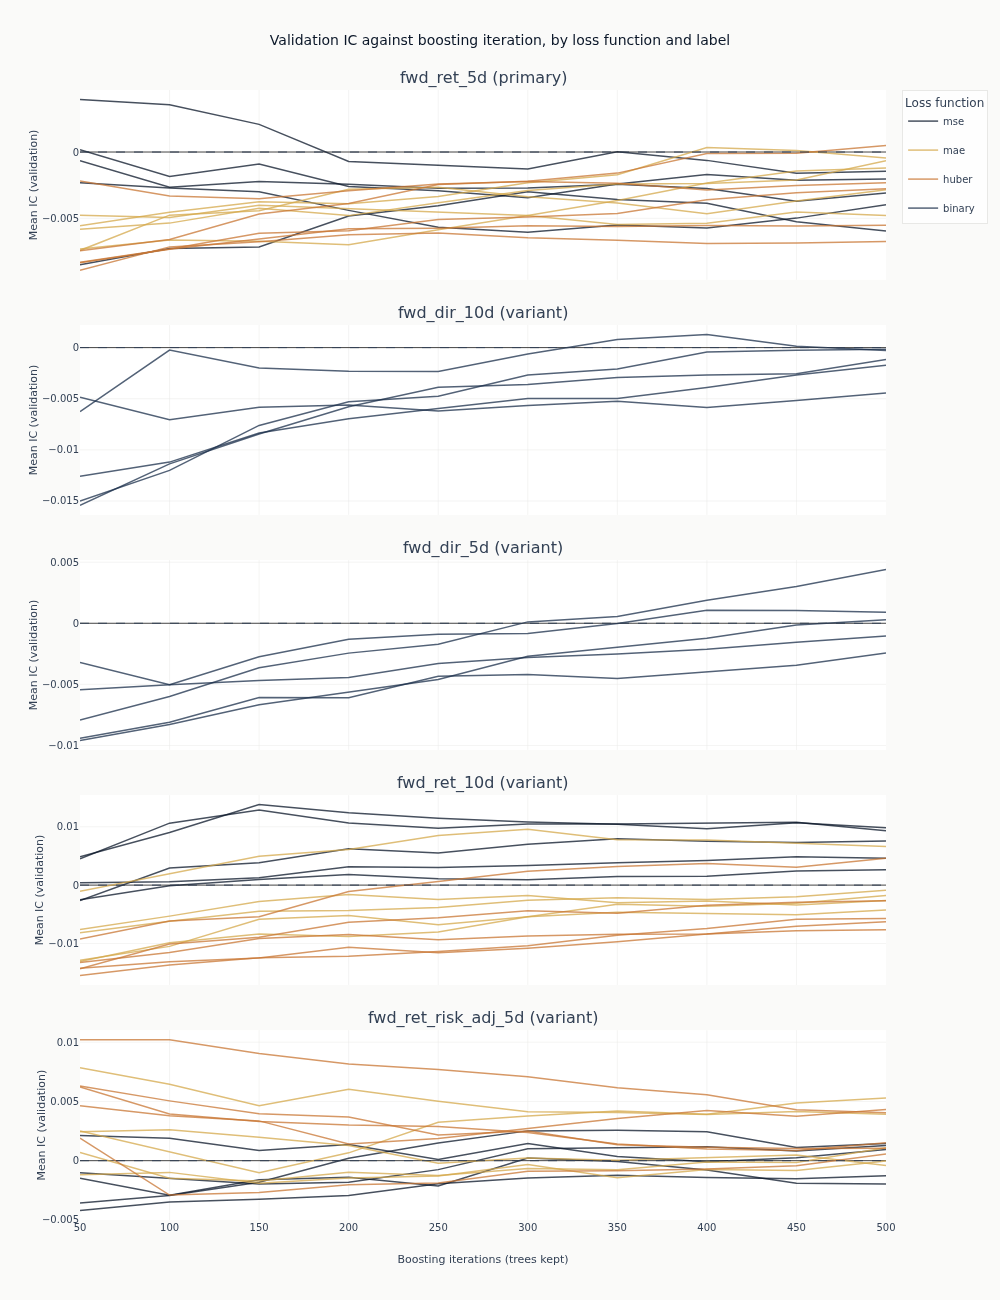

In [11]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {
    "mse": COLORS["blue"],
    "mae": COLORS["amber"],
    "huber": COLORS["copper"],
    "binary": COLORS["slate"],
}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name.

    Raising on an unrecognised name rather than defaulting is the point. The classification
    labels declare `*_binary` configurations, and a default of `mse` drew them in the
    squared-error colour under a legend that said the colour was the loss function.
    """
    match = next((key for key in objectives if name.endswith(key)), None)
    if match is None:
        raise ValueError(f"{name!r} does not end in a declared objective: {sorted(objectives)}")
    return match


fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
drawn_objectives: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for objective, color in objectives.items():
        members = [
            name
            for name in panel.get_column("config_name").unique(maintain_order=True)
            if objective_of(name) == objective
        ]
        for config_name in members:
            series = panel.filter(pl.col("config_name") == config_name)
            fig_curves.add_trace(
                go.Scatter(
                    x=series.get_column("checkpoint_value").to_list(),
                    y=series.get_column("ic_mean").to_list(),
                    mode="lines",
                    name=objective,
                    legendgroup=objective,
                    # One legend entry per loss function, not per configuration: the colour is
                    # the claim, and fifty-five named lines would bury it.
                    showlegend=objective not in drawn_objectives,
                    line=dict(color=color, width=1.5),
                    opacity=0.75,
                ),
                row=row,
                col=1,
            )
            drawn_objectives.add(objective)
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function and label",
    height=260 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Loss function"),
)
# Which panels sit above zero is a fact about the frame, so the alt text reads it. Describing the
# whole chart as sitting below zero was true of the one label this notebook used to fit.
side_text = "; ".join(
    f"{row['label']} has {row['n_positive']} of {row['candidates']} above zero"
    for row in by_label.sort("label").iter_rows(named=True)
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: dark navy for squared error, gold for absolute "
    "error, copper for Huber, slate for the binary objective the classification labels declare. "
    "One panel per label, sharing the iteration axis, each with a dashed zero line. Counted from "
    f"the frame: {side_text}. Within any one panel the lines wander up and down rather than "
    "rising to a common peak and falling away.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three regression colours should separate,
and they should separate more as trees are added, since each additional tree is fitted to the
residuals the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact. The configurations are held in one order across
the panels - their ranking on the primary label - so a panel that does not descend is a label
that orders the grid differently.

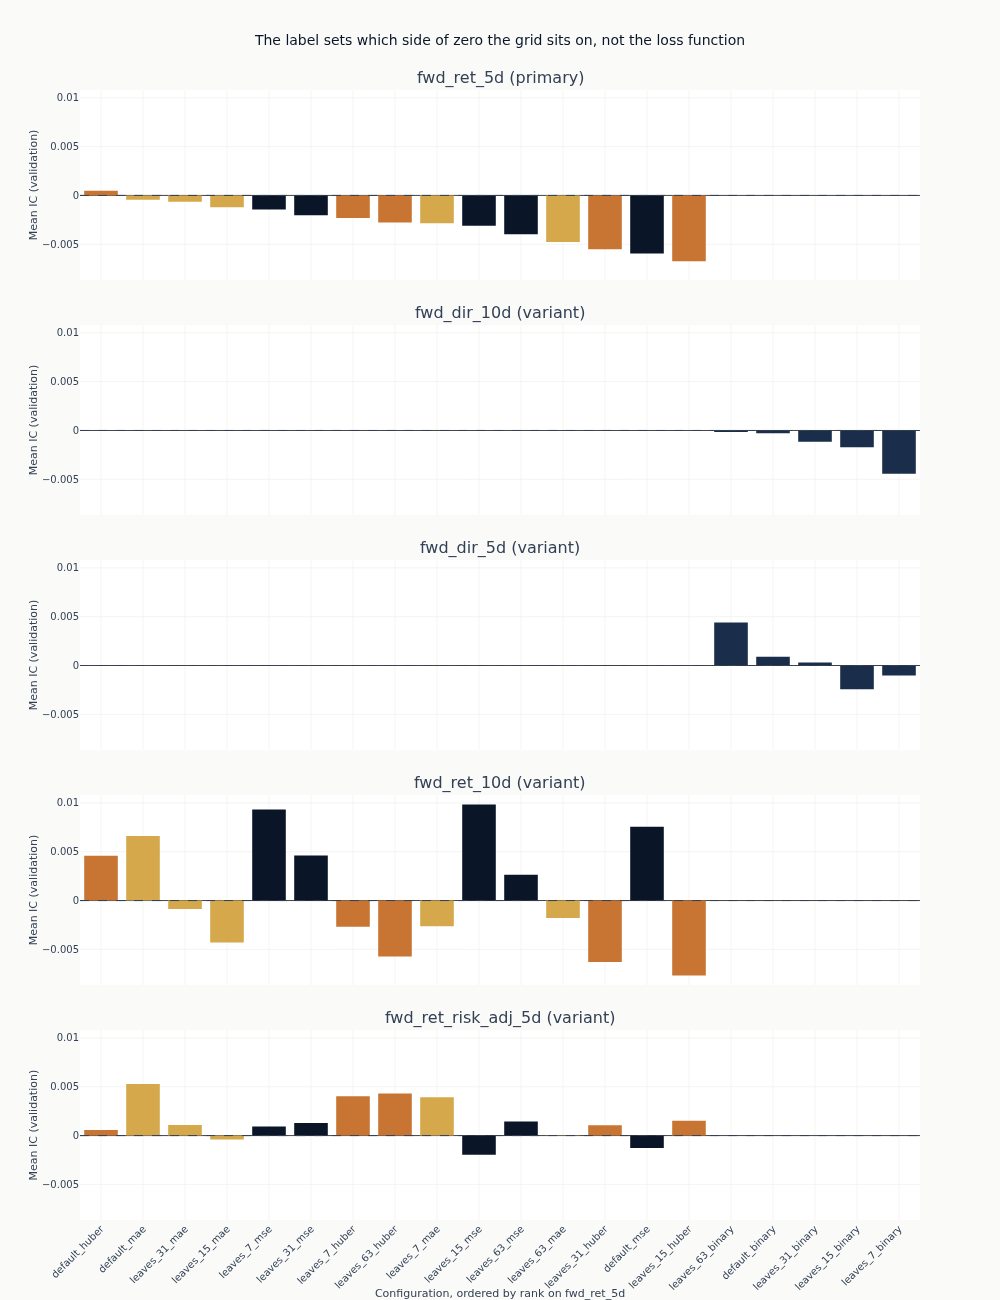

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iteration = int(final.get_column("checkpoint_value").max())
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

# `shared_yaxes` matches axes across columns, so with one column it does nothing and each
# panel would be rescaled to fill itself. Matching every row to the first is what puts the
# labels on one vertical scale, which is what stacking them is for.
fig_obj = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    # The classification labels declare their own configurations; they keep them and append them
    # after the shared order rather than being dropped from the figure.
    order = [name for name in config_order if name in set(panel.get_column("config_name"))]
    order += [name for name in panel.get_column("config_name").to_list() if name not in order]
    panel = panel.with_columns(
        rank=pl.col("config_name").replace_strict(
            {name: index for index, name in enumerate(order)}, return_dtype=pl.Int32
        )
    ).sort("rank")
    fig_obj.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[
                objectives[objective_of(name)] for name in panel.get_column("config_name")
            ],
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig_obj.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_obj.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_obj.update_yaxes(matches="y", row=row, col=1)
fig_obj.update_xaxes(
    title_text=f"Configuration, ordered by rank on {order_label}",
    tickangle=-45,
    row=len(panel_labels),
    col=1,
)
fig_obj.update_layout(
    title="The label sets which side of zero the grid sits on, not the loss function",
    height=260 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
)
# `side_text` counts every checkpoint; this chart shows one, so it gets its own count rather
# than borrowing a number taken over a larger set.
final_side_text = "; ".join(
    f"{row['label']} has {row['n_positive']} of {row['configurations']} above zero"
    for row in (
        final.group_by("label")
        .agg(
            configurations=pl.len(),
            n_positive=(pl.col("ic_mean") > 0).sum(),
        )
        .sort("label")
        .iter_rows(named=True)
    )
)
show_plotly_with_alt(
    fig_obj,
    "Bar charts of mean validation information coefficient at the final boosting iteration, one "
    "panel per label on one shared vertical scale, bars coloured by loss function and held in "
    "the primary label's ranking order in every panel. Within a panel the colours are "
    "interleaved across the ranking rather than grouped, so the loss function does not order the "
    f"grid. Counted at this checkpoint: {final_side_text}. Each panel carries a dashed zero "
    "line.",
)

### How much the checkpoint moves a configuration

One number per label and configuration: the range its IC covers across its own ten checkpoints.
This is the quantity that decides whether choosing a stopping point is a decision worth making
carefully or one being made by noise. A configuration whose IC varies more across its own
training run than the configurations vary among themselves is one where the checkpoint, not the
model, is doing the ranking. Both quantities are computed inside a label, because comparing a
within-run range against a spread taken across labels would compare two different things.

In [13]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
checkpoint_vs_grid = (
    spread.group_by("label")
    .agg(median_checkpoint_range=pl.col("checkpoint_range").median())
    .join(
        final.group_by("label").agg(
            across_configurations=pl.col("ic_mean").max() - pl.col("ic_mean").min()
        ),
        on="label",
    )
    .with_columns(
        checkpoint_dominates=pl.col("median_checkpoint_range") > pl.col("across_configurations")
    )
    .sort("label")
)
print(f"compared at {final_iteration} boosting iterations")
checkpoint_vs_grid

compared at 500 boosting iterations


label,median_checkpoint_range,across_configurations,checkpoint_dominates
str,f64,f64,bool
"""fwd_dir_10d""",0.010871,0.004277,true
"""fwd_dir_5d""",0.00698,0.006827,true
"""fwd_ret_10d""",0.008584,0.0175,false
"""fwd_ret_5d""",0.003736,0.007233,false
"""fwd_ret_risk_adj_5d""",0.003252,0.007256,false


## 5. What to notice

**Read `checkpoint_dominates` before reading any ranking.** Where the median within-run IC range
exceeds the spread across the whole grid, the leading configuration for that label was chosen by
where its training run happened to be when it was measured, not by anything about the model. The
ranking is still a real ordering of registered candidates - `14_backtest` selects over all of
them - but it is not evidence that one configuration is better than another.

**The label decides how much of the grid clears zero; the grid itself does not.** Read
`n_positive` against `candidates` in `by_label`: the three regression labels share a menu, a
feature set and a fold schedule, and the share of their candidates that clears zero is not
the same. What moves is which target the ranking is asked about. This is not a claim that
the labels are further apart than the grid is wide: read `best_ic` against `worst_ic` in the
same frame and one regression label's own candidates span more than the leading candidates
span across all five labels. Both readings come off the same frame and they say different
things - the grid is where the magnitude lives, the label is where the sign lives. The linear notebook reaches the same place, which matters - two model families with very
different representational power agree about which target these features rank, and that points
at the target rather than at either model.

**These features forecast dispersion rather than direction, and the label set tests it.** Implied
volatility says how wide the market expects the distribution to be, skew how asymmetric, the term
structure how that changes with horizon, the variance risk premium how much the market charges
for bearing it. None is a claim about the *mean*, which is what a forward return is. A
risk-adjusted return divides that mean by a measure of width, so a feature set that forecasts
width well should rank it better than the raw return. The `by_label` frame is where that
prediction meets the evidence.

**The loss function does not separate the results, and that is worth stating.** In case studies
whose labels have heavy tails the three regression objectives order themselves consistently -
Huber, then absolute error, then squared error - because squared error spends the fit on extremes
a rank metric does not reward. Here the colours interleave. That is the control working: these
labels are equity returns over days, whose tails are mild next to a short straddle's or a
perpetual's, and where the tails are mild the choice of objective stops mattering. A reader who
took "always prefer Huber" from another notebook in this book should take this one as the
boundary of that rule.

**The sample is two folds, one of them 2020.** Every number above is an average over two
validation windows of a short dataset, one covering a year in which the option surface behaved
unlike any other in the sample. That is enough to say an effect is not large; it is not enough to
characterise one, and it applies to whichever label leads as much as to the ones that do not.

**None of this selects anything.** IC measures whether predictions rank stocks correctly, not
whether a strategy trading them makes money after costs and turnover. Selection is on validation
backtest Sharpe over the population just published, in [`14_backtest`](14_backtest.ipynb), where
the checkpoint is part of what is selected.

**Known limitations.** Two folds. The IC is an average of daily rank correlations with no
adjustment for the serial dependence overlapping multi-day returns create, so it is a diagnostic
rather than a test. The grid varies capacity and loss at a fixed learning rate. And every number
is measured on validation folds already read many times by the time a case study reaches this
notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) fits a neural network to the same rows, and
[`11_latent_factors`](11_latent_factors.ipynb) asks whether the surface has structure that a
supervised model is the wrong instrument for. Given that two supervised families have now agreed
about which label they can rank, the latent-factor route is the more interesting of the two.